In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')   # unnecessary warnings hide karne ke liye

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1021,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1022,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1023,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
x = df.drop('target',axis=1)
y= df.target

In [10]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [12]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.20, random_state=42)

In [17]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
Model = LogisticRegression()
Model.fit(x,y)

LogisticRegression()

In [19]:
y_predic = Model.predict(x_test_scaled)
y_predic_prob = Model.predict_proba(x_test_scaled)
print (y_predic)


[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1 0 1
 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1
 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 1 0 1 1
 1 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0]


In [20]:
print (y_predic_prob)

[[7.37720320e-03 9.92622797e-01]
 [2.60632125e-04 9.99739368e-01]
 [9.91580996e-01 8.41900396e-03]
 [5.49729986e-03 9.94502700e-01]
 [9.91042226e-01 8.95777376e-03]
 [1.17286392e-01 8.82713608e-01]
 [9.92729719e-01 7.27028145e-03]
 [9.98125527e-01 1.87447273e-03]
 [2.16341655e-01 7.83658345e-01]
 [9.91309685e-01 8.69031454e-03]
 [2.81709393e-03 9.97182906e-01]
 [9.97966645e-01 2.03335527e-03]
 [8.71698656e-02 9.12830134e-01]
 [3.84808022e-01 6.15191978e-01]
 [9.29051959e-01 7.09480412e-02]
 [4.31748354e-02 9.56825165e-01]
 [9.93259120e-01 6.74088010e-03]
 [8.42153470e-02 9.15784653e-01]
 [2.73722445e-01 7.26277555e-01]
 [9.90383496e-01 9.61650435e-03]
 [4.19117256e-02 9.58088274e-01]
 [9.55944284e-01 4.40557155e-02]
 [6.03804977e-01 3.96195023e-01]
 [9.92647902e-01 7.35209833e-03]
 [4.19117256e-02 9.58088274e-01]
 [3.98252995e-01 6.01747005e-01]
 [1.64959876e-03 9.98350401e-01]
 [3.96410694e-01 6.03589306e-01]
 [9.21415461e-01 7.85845390e-02]
 [2.11088746e-02 9.78891125e-01]
 [1.923306

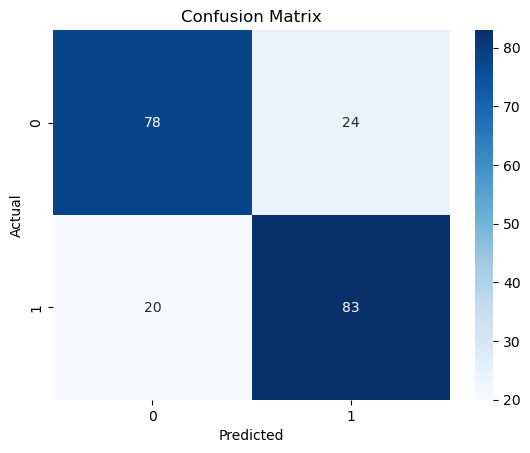

In [21]:
cm = confusion_matrix(y_test, y_predic)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
print(classification_report(y_test, y_predic))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78       102
           1       0.78      0.81      0.79       103

    accuracy                           0.79       205
   macro avg       0.79      0.79      0.79       205
weighted avg       0.79      0.79      0.79       205

